# Clustering de clientes de tarjetas de crédito

Este notebook compara **K-Means**, clustering jerárquico aglomerativo y **DBSCAN** sobre el archivo `CC GENERAL.csv`.

## tl;dr

K-Means con **3 clusters** obtuvo el mejor silhouette (**0,251**). Los perfiles identificados son: **uso básico** (68,4%), **compradores frecuentes de alto valor** (13,8%) y **usuarios intensivos de adelantos de efectivo** (17,8%). Los resultados se recalculan al ejecutar el notebook.

## Contexto y método

### Supuestos clave

- `CUST_ID` identifica al cliente y no se usa como variable para clustering.
- Los valores faltantes se imputan con la mediana de su columna.
- Las variables se estandarizan antes de entrenar los modelos.
- Se prueba K-Means con 2 a 8 clusters y se selecciona el mayor silhouette.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path.cwd() / 'CC GENERAL.csv'
OUTPUT_DIR = Path.cwd() / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

assert DATA_PATH.exists(), f'No se encontró el archivo: {DATA_PATH}'

## Datos

### 1. Cargar y revisar los datos

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f'Dimensiones: {raw_df.shape[0]:,} filas y {raw_df.shape[1]} columnas')
display(raw_df.head())
display(raw_df.isna().sum().loc[lambda serie: serie > 0].to_frame('valores_nulos'))

Dimensiones: 8,950 filas y 18 columnas


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


,valores_nulos
CREDIT_LIMIT,1
MINIMUM_PAYMENTS,313


### 2. Preparar las variables

Se excluye el identificador, se imputan los nulos y se estandarizan todas las variables numéricas.

In [3]:
feature_df = raw_df.drop(columns='CUST_ID').copy()
imputer = SimpleImputer(strategy='median')
feature_df = pd.DataFrame(
    imputer.fit_transform(feature_df), columns=feature_df.columns, index=feature_df.index
)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(feature_df)
print(f'Nulos después de imputar: {feature_df.isna().sum().sum()}')
print(f'Variables utilizadas: {feature_df.shape[1]}')

Nulos después de imputar: 0
Variables utilizadas: 17


## Resultados

### 3. Seleccionar el número de clusters para K-Means

In [4]:
candidates = []
for n_clusters in range(2, 9):
    model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(features_scaled)
    candidates.append({
        'n_clusters': n_clusters,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(features_scaled, labels),
    })

kmeans_selection = pd.DataFrame(candidates)
best_k = int(kmeans_selection.loc[kmeans_selection['silhouette'].idxmax(), 'n_clusters'])
display(kmeans_selection.style.format({'inertia': '{:,.2f}', 'silhouette': '{:.3f}'}))
print(f'K seleccionado: {best_k}')

C:\Users\Yo\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Yo\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,n_clusters,inertia,silhouette
0,2,"127,784.53",0.210
1,3,"111,973.97",0.251
2,4,"99,061.94",0.198
3,5,"91,490.50",0.193
4,6,"84,826.59",0.203
5,7,"79,506.96",0.215
6,8,"74,484.88",0.222


K seleccionado: 3


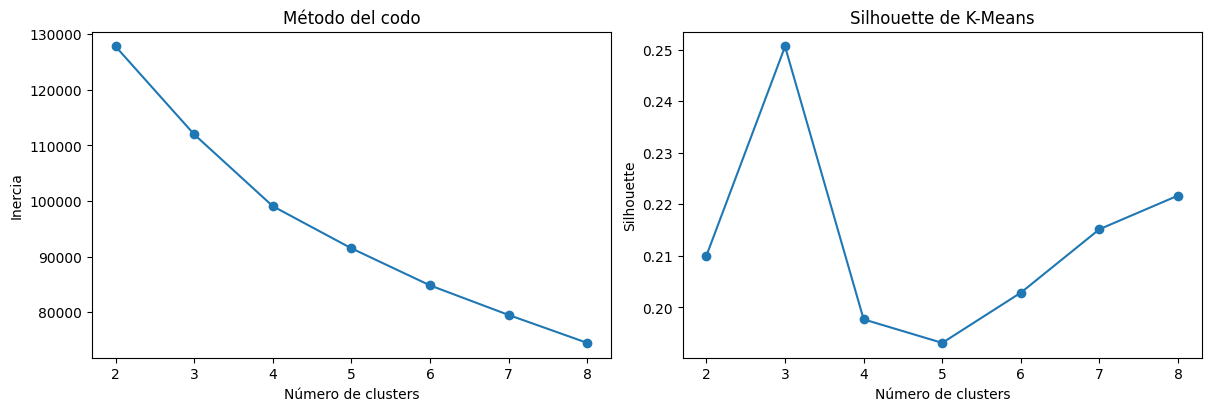

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(kmeans_selection['n_clusters'], kmeans_selection['inertia'], marker='o')
axes[0].set(title='Método del codo', xlabel='Número de clusters', ylabel='Inercia')
axes[1].plot(kmeans_selection['n_clusters'], kmeans_selection['silhouette'], marker='o')
axes[1].set(title='Silhouette de K-Means', xlabel='Número de clusters', ylabel='Silhouette')
plt.show()

### 4. Entrenar y comparar los tres métodos

Cada algoritmo se entrena y se evalúa de forma independiente antes de ver la comparación final.

In [6]:
def valid_silhouette(features, labels):
    unique_labels = set(labels)
    if len(unique_labels) < 2 or len(unique_labels) == len(features):
        return None
    return silhouette_score(features, labels)

#### 4.1 K-Means

In [7]:
kmeans_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans_model.fit_predict(features_scaled)
kmeans_silhouette = valid_silhouette(features_scaled, kmeans_labels)
print(f'Clusters: {len(set(kmeans_labels))}')
print(f'Silhouette: {kmeans_silhouette:.3f}')

Clusters: 3
Silhouette: 0.251


#### 4.2 Clustering aglomerativo

In [8]:
agglomerative_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agglomerative_labels = agglomerative_model.fit_predict(features_scaled)
agglomerative_silhouette = valid_silhouette(features_scaled, agglomerative_labels)
print(f'Clusters: {len(set(agglomerative_labels))}')
print(f'Silhouette: {agglomerative_silhouette:.3f}')

Clusters: 3
Silhouette: 0.167


#### 4.3 DBSCAN

In [9]:
min_samples = 5
distances, _ = NearestNeighbors(n_neighbors=min_samples).fit(features_scaled).kneighbors(features_scaled)
eps = float(pd.Series(distances[:, -1]).quantile(0.90))
dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan_model.fit_predict(features_scaled)
non_noise = dbscan_labels != -1
cluster_sizes = pd.Series(dbscan_labels[non_noise]).value_counts()
minimum_size = max(20, int(non_noise.sum() * 0.01))
dbscan_silhouette = (
    valid_silhouette(features_scaled[non_noise], dbscan_labels[non_noise])
    if len(cluster_sizes) > 1 and cluster_sizes.min() >= minimum_size else None
)
print(f'eps: {eps:.3f} | min_samples: {min_samples}')
print(f'Clusters: {len(set(dbscan_labels)) - int(-1 in dbscan_labels)}')
print(f'Puntos de ruido: {(dbscan_labels == -1).sum()}')
print('Silhouette: no comparable' if dbscan_silhouette is None else f'Silhouette: {dbscan_silhouette:.3f}')

eps: 1.967 | min_samples: 5
Clusters: 2
Puntos de ruido: 621
Silhouette: no comparable


#### 4.4 Comparación final y visualización

,method,clusters,noise_points,silhouette
0,K-Means,3,0,0.251
1,Agglomerative,3,0,0.167
2,DBSCAN,2,621,nan


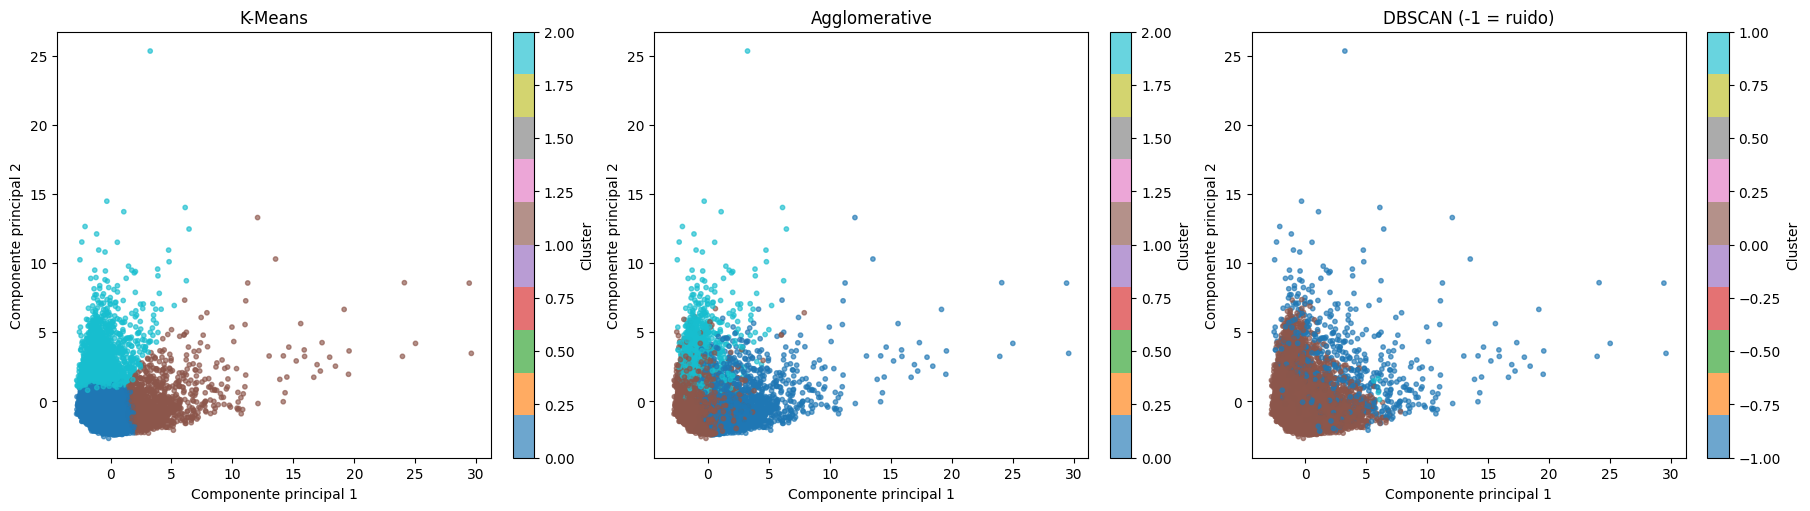

In [10]:
metrics = pd.DataFrame([
    {'method': 'K-Means', 'clusters': len(set(kmeans_labels)), 'noise_points': 0, 'silhouette': kmeans_silhouette},
    {'method': 'Agglomerative', 'clusters': len(set(agglomerative_labels)), 'noise_points': 0, 'silhouette': agglomerative_silhouette},
    {'method': 'DBSCAN', 'clusters': len(set(dbscan_labels)) - int(-1 in dbscan_labels), 'noise_points': int((dbscan_labels == -1).sum()), 'silhouette': dbscan_silhouette},
])
display(metrics.style.format({'silhouette': '{:.3f}'}))

pca_features = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(features_scaled)
methods = [('K-Means', kmeans_labels), ('Agglomerative', agglomerative_labels), ('DBSCAN (-1 = ruido)', dbscan_labels)]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for axis, (name, labels) in zip(axes, methods):
    scatter = axis.scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', s=10, alpha=0.65)
    axis.set(title=name, xlabel='Componente principal 1', ylabel='Componente principal 2')
    fig.colorbar(scatter, ax=axis, label='Cluster')
plt.show()

## Perfilado de segmentos K-Means

### 5. Tamaño y validación de los clusters

Se valida que todos los clientes tengan exactamente una asignación y que los porcentajes de los segmentos sumen 100%.

In [11]:
assert len(kmeans_labels) == len(raw_df), 'Faltan asignaciones de K-Means'
assert pd.Series(kmeans_labels).notna().all(), 'Hay asignaciones nulas'

cluster_sizes = (
    pd.Series(kmeans_labels, name='cluster')
    .value_counts()
    .sort_index()
    .rename('clientes')
    .to_frame()
)
cluster_sizes['porcentaje'] = cluster_sizes['clientes'] / cluster_sizes['clientes'].sum() * 100
assert cluster_sizes['clientes'].sum() == len(raw_df), 'No todos los clientes fueron asignados'
assert abs(cluster_sizes['porcentaje'].sum() - 100) < 1e-9, 'Los porcentajes no suman 100%'
display(cluster_sizes.style.format({'porcentaje': '{:.1f}%'}))

,clientes,porcentaje
cluster,,
0,6119,68.4%
1,1235,13.8%
2,1596,17.8%


### 6. Perfil financiero por cluster

Se comparan medias y medianas de las variables más relevantes para negocio. La media muestra la magnitud promedio y la mediana reduce el efecto de valores extremos.

In [12]:
business_columns = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
    'PAYMENTS', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY'
]
profile_source = feature_df.assign(cluster=kmeans_labels)
profile_summary = profile_source.groupby('cluster')[business_columns].agg(['mean', 'median']).round(2)
display(profile_summary)

BALANCE          PURCHASES          CASH_ADVANCE           \
            mean   median      mean   median         mean   median   
cluster                                                              
0         799.75   424.97    505.53   304.60       330.82     0.00   
1        2220.00  1239.89   4268.52  3129.67       458.42     0.00   
2        3989.14  3460.59    384.53     0.00      3866.21  3099.14   

        CREDIT_LIMIT         PAYMENTS          PRC_FULL_PAYMENT         \
                mean  median     mean   median             mean median   
cluster                                                                  
0            3271.51  2500.0   909.68   569.82             0.16   0.00   
1            7733.97  7000.0  4151.28  2764.89             0.30   0.08   
2            6675.44  6000.0  3019.11  1648.48             0.03   0.00   

        PURCHASES_FREQUENCY        CASH_ADVANCE_FREQUENCY         
                       mean median                   mean median  
cluster                                                           
0                      0.47   0.42                   0.07   0.00  
1                      0.95   1.00                   0.06   0.00  
2                      0.23   0.00                   0.45   0.42

### 7. Comparación visual

El mapa de calor muestra las medias estandarizadas dentro de cada variable: valores positivos están por encima del promedio general y negativos por debajo.

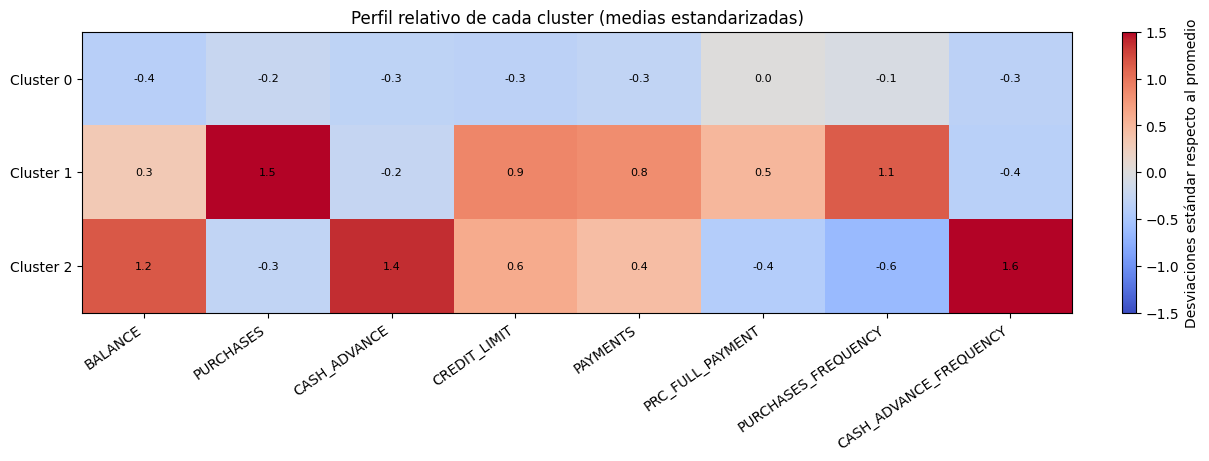

In [13]:
profile_means = profile_source.groupby('cluster')[business_columns].mean()
profile_standardized = (profile_means - feature_df[business_columns].mean()) / feature_df[business_columns].std()

fig, axis = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
image = axis.imshow(profile_standardized, cmap='coolwarm', aspect='auto', vmin=-1.5, vmax=1.5)
axis.set_xticks(range(len(business_columns)), business_columns, rotation=35, ha='right')
axis.set_yticks(range(len(profile_standardized.index)), [f'Cluster {cluster}' for cluster in profile_standardized.index])
axis.set_title('Perfil relativo de cada cluster (medias estandarizadas)')
for row in range(profile_standardized.shape[0]):
    for column in range(profile_standardized.shape[1]):
        axis.text(column, row, f'{profile_standardized.iloc[row, column]:.1f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=axis, label='Desviaciones estándar respecto al promedio')
plt.show()

### 7.1 Gráficos comparativos de los tres clusters

Los gráficos muestran el tamaño de cada segmento, sus promedios financieros y sus patrones de frecuencia de uso.

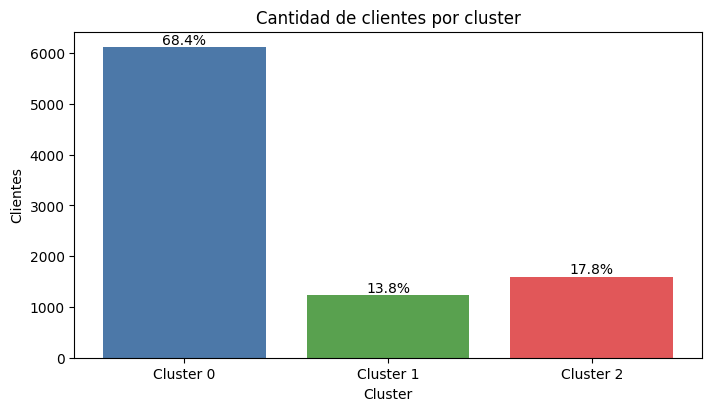

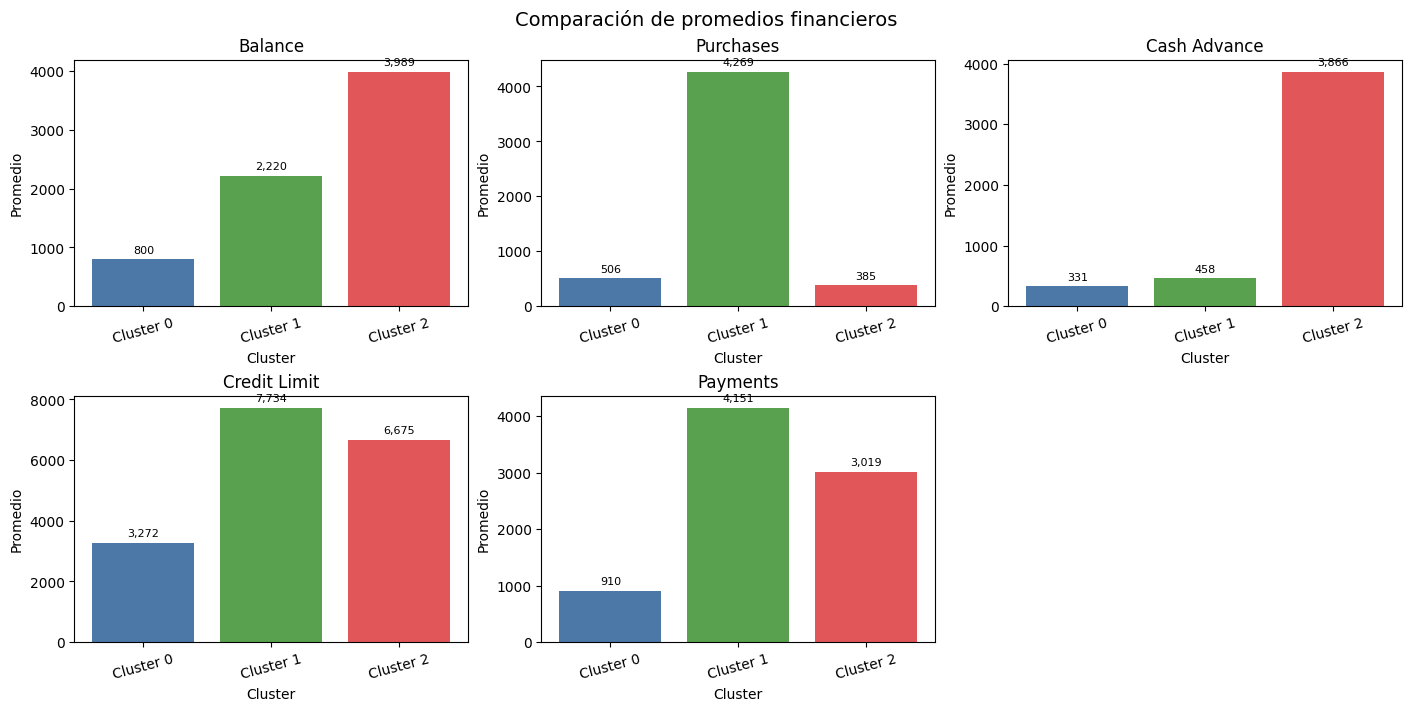

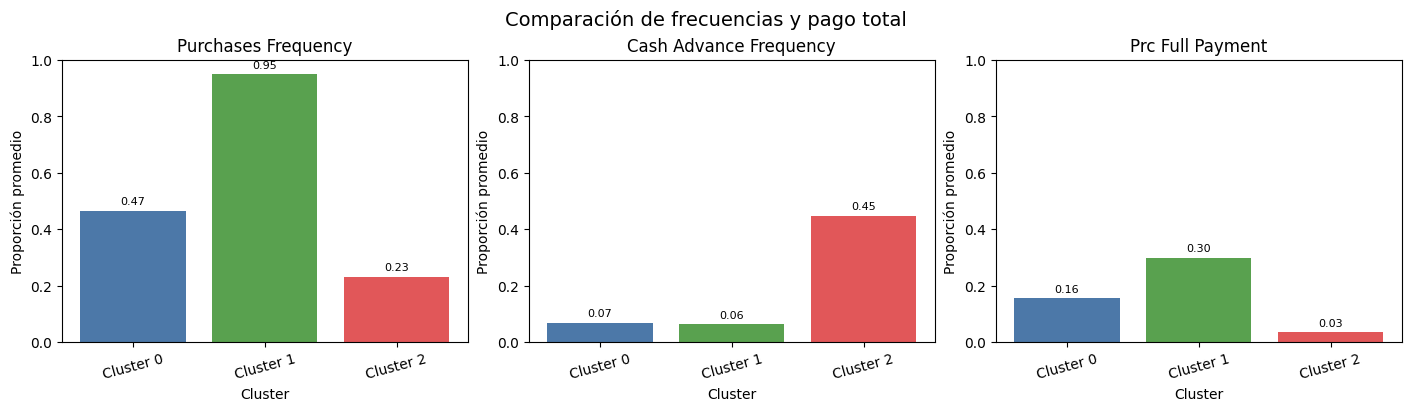

In [14]:
cluster_labels = [f'Cluster {cluster}' for cluster in profile_means.index]
colors = ['#4C78A8', '#59A14F', '#E15759']

fig, axis = plt.subplots(figsize=(7, 4), constrained_layout=True)
bars = axis.bar(cluster_labels, cluster_sizes['clientes'], color=colors)
axis.set(title='Cantidad de clientes por cluster', xlabel='Cluster', ylabel='Clientes')
for bar, percentage in zip(bars, cluster_sizes['porcentaje']):
    axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percentage:.1f}%', ha='center', va='bottom')
plt.show()

financial_variables = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
for axis, variable in zip(axes.flat, financial_variables):
    bars = axis.bar(cluster_labels, profile_means[variable], color=colors)
    axis.set(title=variable.replace('_', ' ').title(), xlabel='Cluster', ylabel='Promedio')
    axis.tick_params(axis='x', rotation=15)
    axis.bar_label(bars, labels=[f'{value:,.0f}' for value in profile_means[variable]], padding=3, fontsize=8)
axes.flat[-1].axis('off')
fig.suptitle('Comparación de promedios financieros', fontsize=14)
plt.show()

frequency_variables = ['PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT']
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for axis, variable in zip(axes, frequency_variables):
    bars = axis.bar(cluster_labels, profile_means[variable], color=colors)
    axis.set(title=variable.replace('_', ' ').title(), xlabel='Cluster', ylabel='Proporción promedio', ylim=(0, 1))
    axis.tick_params(axis='x', rotation=15)
    axis.bar_label(bars, labels=[f'{value:.2f}' for value in profile_means[variable]], padding=3, fontsize=8)
fig.suptitle('Comparación de frecuencias y pago total', fontsize=14)
plt.show()

### 8. Nombres, interpretación y acciones

Los nombres se asignan a partir de las diferencias observadas en la tabla y el gráfico anteriores.

In [15]:
segment_names = {
    0: 'Uso básico / bajo gasto',
    1: 'Compradores frecuentes de alto valor',
    2: 'Usuarios intensivos de adelantos de efectivo',
}
segment_actions = {
    0: 'Activar uso: ofertas simples, beneficios por primera compra y recordatorios de valor.',
    1: 'Fidelizar: beneficios premium, cuotas y propuestas acordes a su alto uso y límite.',
    2: 'Gestionar riesgo y necesidad de liquidez: seguimiento preventivo, alternativas de financiación y educación financiera.',
}
segment_interpretation = {
    0: 'Saldos, compras y adelantos bajos; representa un uso ocasional o básico de la tarjeta.',
    1: 'Compras y frecuencia de compra muy altas, junto con límites y pagos elevados.',
    2: 'Saldo y adelantos de efectivo altos, compras bajas y menor proporción de pago total.',
}
segment_overview = cluster_sizes.copy()
segment_overview['segmento'] = segment_overview.index.map(segment_names)
segment_overview['interpretacion'] = segment_overview.index.map(segment_interpretation)
segment_overview['accion_recomendada'] = segment_overview.index.map(segment_actions)
display(segment_overview[['segmento', 'clientes', 'porcentaje', 'interpretacion', 'accion_recomendada']].style.format({'porcentaje': '{:.1f}%'}))

,segmento,clientes,porcentaje,interpretacion,accion_recomendada
cluster,,,,,
0,Uso básico / bajo gasto,6119,68.4%,"Saldos, compras y adelantos bajos; representa un uso ocasional o básico de la tarjeta.","Activar uso: ofertas simples, beneficios por primera compra y recordatorios de valor."
1,Compradores frecuentes de alto valor,1235,13.8%,"Compras y frecuencia de compra muy altas, junto con límites y pagos elevados.","Fidelizar: beneficios premium, cuotas y propuestas acordes a su alto uso y límite."
2,Usuarios intensivos de adelantos de efectivo,1596,17.8%,"Saldo y adelantos de efectivo altos, compras bajas y menor proporción de pago total.","Gestionar riesgo y necesidad de liquidez: seguimiento preventivo, alternativas de financiación y educación financiera."


### 5. Exportar resultados

Los resultados se guardan en la carpeta `outputs`, junto al notebook.

In [16]:
clustered_df = raw_df[['CUST_ID']].join(feature_df)
clustered_df['cluster_kmeans'] = kmeans_labels
clustered_df['segmento_kmeans'] = pd.Series(kmeans_labels, index=clustered_df.index).map(segment_names)
clustered_df['cluster_agglomerative'] = agglomerative_labels
clustered_df['cluster_dbscan'] = dbscan_labels

clustered_df.to_csv(OUTPUT_DIR / 'credit_card_clusters.csv', index=False)
metrics.to_csv(OUTPUT_DIR / 'clustering_metrics.csv', index=False)
profile_summary.to_csv(OUTPUT_DIR / 'kmeans_cluster_profiles.csv')
print(f'Resultados guardados en: {OUTPUT_DIR.resolve()}')

Resultados guardados en: C:\Credit Card Clustering\outputs


## Conclusiones

- **K-Means** fue el método seleccionado porque alcanzó el mayor silhouette (0,251) entre los métodos comparados.
- El cluster 0 reúne el **68,4%** de los clientes y representa un segmento de uso básico o bajo gasto.
- El cluster 1 reúne el **13,8%** y corresponde a compradores frecuentes de alto valor.
- El cluster 2 reúne el **17,8%** y se caracteriza por un uso intensivo de adelantos de efectivo, por lo que requiere seguimiento preventivo.
- La separación es exploratoria: el silhouette moderado indica que los segmentos sirven como punto de partida y deben complementarse con criterios de negocio.